In [1]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv('ds_salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


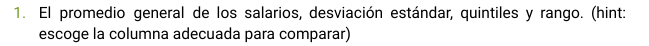

In [10]:
#promedio general
mean_usd = df['salary_in_usd'].mean()
mean_usd

137570.38988015978

In [14]:
#desviación estandar
std_uds = df['salary_in_usd'].std()
std_uds

63055.625278224084

In [16]:
#quintiles
quantile_usd = df['salary_in_usd'].quantile([0.20,0.4,0.6,0.8])
quantile_usd

0.2     83972.8
0.4    120000.0
0.6    149850.0
0.8    185900.0
Name: salary_in_usd, dtype: float64

In [18]:
#rango
max_usd = df['salary_in_usd'].max()
min_usd = df['salary_in_usd'].min()

In [20]:
range_usd = max_usd - min_usd
range_usd

444868

conclusión:
Escogí la columna SALARY IN USD asumiendo que corresponde a los sueldos líquidos, lo que, generaria que los sueldos son los mas cercanos a la realidad.

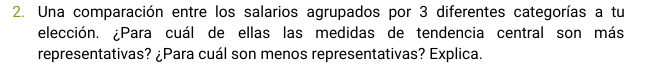

In [52]:
experience_level_salary = df.groupby(['experience_level'])['salary_in_usd'].agg(['mean','median',lambda x:x.value_counts().index[0]])
experience_level_salary

,mean,median,<lambda_0>
experience_level,,,
EN,78546.284375,70000.0,100000
EX,194930.929825,196000.0,200000
MI,104525.939130,100000.0,100000
SE,153051.071542,146000.0,120000


In [54]:
employment_type_salary = df.groupby(['employment_type'])['salary_in_usd'].agg(['mean','median',lambda x:x.value_counts().index[0]])
employment_type_salary

,mean,median,<lambda_0>
employment_type,,,
CT,113446.900000,75000.0,30000
FL,51807.800000,50000.0,50000
FT,138314.199570,135000.0,150000
PT,39533.705882,21669.0,12000


In [56]:
company_size_salary = df.groupby(['company_size'])['salary_in_usd'].agg(['mean','median',lambda x:x.value_counts().index[0]])
company_size_salary

,mean,median,<lambda_0>
company_size,,,
L,118300.982379,108500.0,100000
M,143130.548367,140000.0,150000
S,78226.682432,62146.0,50000


**Conclusiones**
1. experience_level:
- con respecto a las medidas en los puntos EN EX MI, se evidencia que son mas certereas entre las 3, sin embargo, se aprecia que la sección SE podrian haber valores atipicos que generarian una mayor dispersión
3. employment_type:
- se evidencia que este punto presenta mayores valores atipicos ya que los promedios y medianas presentan mayor varialibidad en los datos
5. company_size:
- los valores se encuentran similares entre sí, por lo que se puede concluir que las medidas logran ser significativas


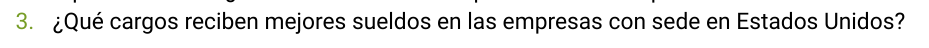

In [100]:
# Filtrar empresas con sede en EE.UU.
us_companies = df[df['company_location'] == 'US']
us_companies

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
5,2023,SE,FT,Applied Scientist,222200,USD,222200,US,0,US,L
6,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
9,2023,SE,FT,Data Scientist,147100,USD,147100,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
3749,2021,SE,FT,Data Specialist,165000,USD,165000,US,100,US,L
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S


In [104]:
#aplicar el groupby en la variable creada de us_companies y seleccionar las 10 mejores
company_us_salary = us_companies.groupby('job_title')['salary_in_usd'].agg('mean').sort_values(ascending = True)
company_us_salary.head(10)

job_title
BI Data Engineer                      60000.000000
Big Data Engineer                     70000.000000
Data Analytics Consultant             81500.000000
BI Data Analyst                       82709.833333
Data Quality Analyst                  82863.333333
Computer Vision Software Engineer     82873.000000
Data Operations Analyst               90562.500000
Data Analytics Specialist             95000.000000
Data Operations Engineer              98485.000000
Financial Data Analyst               101666.666667
Name: salary_in_usd, dtype: float64